# Energy Conservation Check

The goal of this notebook is to validate that energy conservation holds over the duration of the simulation.

In [5]:
#First import the various libraries needed
import sys
sys.path.append('/storage/home/hcoda1/9/dmathews33/Spin-tracking/scripts')
import nedmSim
import numpy as np
import matplotlib.pyplot as plt

In [6]:
tf = 500.0
tout = 10.0
numParticles = 65536
seed = 0

parameters = {}
parameters['particle'] = 'neutron' #choose particle type
parameters['dist'] = 'C' #velocity distribution method
parameters['T']='0.4' #set the temperature if using the distribution = 'M' option
parameters['gas_coll']='false' #are we doing phonon collisions? yes for helium-3 usually
parameters['diffuse']='0.1' #diffuse collisions? 0 = specular, 1 = diffuse, 0.5 is 50% diffuse, etc
parameters['gravity']='true' #gravity on or off?
parameters['B0'] = '3.0e-6, 0, 0' #magnetic field
parameters['numParticles'] = str(numParticles) #number of particles
parameters['numPerGPUBlock'] = '256' #number of particles per GPU block, does nothing on CPU
parameters['t0']='0.0' #start time of the simulation
parameters['tf']=str(tf) #stop time of the simulation
parameters['ioutInt']=str(tout) #output interval
parameters['a']= '0' #'19.1024180e-6' #driving field amplitude
parameters['w']='0' #'3000.0' #driving field frequency
parameters['h']='1e-5' #starting step size
parameters['keepStepSize'] = 'false' #do we remember the step size between function calls
parameters['fixedStepSize'] = 'false' #is the step size for spin integration fixed?
parameters['rtol'] = '1.0e-12' #relative precision desired for spin integration
parameters['atol'] = '1.0e-12' #absolute precision desired for spin integration
parameters['hmax'] = '1.0' #largest step size allowed for spin integration
parameters['hmin'] = '1.0e-9' #smallest step size allowed for spin integration
parameters['seed'] = str(seed) #random number seed for the first particle
parameters['integratorType'] = '-1' #the spin integration method
parameters['V'] = '5.0'

filenameDiffuse = 'energytestDiffuse.txt'
nedmSim.writeParameterFile(filenameDiffuse, parameters)

parameters['diffuse'] = '0'
filenameSpecular = 'energytestSpecular.txt'
nedmSim.writeParameterFile(filenameSpecular, parameters)

outputNameDiffuse = '/storage/home/hcoda1/9/dmathews33/scratch/energyConservationTestDiffuse.out'
outputNameSpecular = '/storage/home/hcoda1/9/dmathews33/scratch/energyConservationTestSpecular.out'

In [14]:
!~/Spin-tracking/bit64main {filenameDiffuse} {outputNameDiffuse}
!~/Spin-tracking/bit64main {filenameSpecular} {outputNameSpecular}

648
43008, -10.256251 z W 0.015408 -1.309657 3.526844 3.123638 -1.309657 3.678000 -3.123638 : pos_old 0.012928 -0.010698 -0.151870 : pos -0.007251 0.044809 -0.200000
32768, -10.256251 x W 0.005894 3.767495 2.951349 -1.323209 -3.767495 3.009169 -1.323209 : pos_old -0.012794 -0.000540 0.080947 : pos -0.035000 0.017026 0.073148
32768, -10.135115 y W 0.010973 3.767495 -2.843708 -1.323209 3.767495 2.951349 -1.323209 : pos_old -0.035000 0.017026 0.073148 : pos 0.006339 0.050000 0.058629
32768, -10.256251 x W 0.007607 -3.767495 -2.918337 -1.323209 3.767495 -2.843708 -1.323209 : pos_old 0.006339 0.050000 0.058629 : pos 0.035000 0.028083 0.048563
32768, -10.256251 x W 0.018580 3.767495 -3.100606 -1.323209 -3.767495 -2.918337 -1.323209 : pos_old 0.035000 0.028083 0.048563 : pos -0.035000 -0.027833 0.023978
32768, -10.256251 y W 0.007070 3.767495 3.169964 -1.323209 3.767495 -3.100606 -1.323209 : pos_old -0.035000 -0.027833 0.023978 : pos -0.008363 -0.050000 0.014622
32768, -10.256251 x W 0.011510

40960, -10.256251 x W 0.011936 2.898808 -2.886992 3.230415 -2.898808 -2.769902 3.230415 : pos_old -0.000400 0.050000 -0.011818 : pos -0.035000 0.016240 0.026740
40960, -10.256251 y W 0.022114 2.898808 3.103926 3.230415 2.898808 -2.886992 3.230415 : pos_old -0.035000 0.016240 0.026740 : pos 0.029103 -0.050000 0.098176
40960, -10.256251 x W 0.002034 -2.898808 3.083969 3.230415 2.898808 3.103926 3.230415 : pos_old 0.029103 -0.050000 0.098176 : pos 0.035000 -0.043706 0.104747
40960, -10.256251 x W 0.024148 2.898808 2.847078 3.230415 -2.898808 3.083969 3.230415 : pos_old 0.035000 -0.043706 0.104747 : pos -0.035000 0.027905 0.182755
40960, -10.256251 z W 0.005338 2.898808 2.794709 -3.230415 2.898808 2.847078 3.230415 : pos_old -0.035000 0.027905 0.182755 : pos -0.019525 0.042964 0.200000
40960, -10.249930 y W 0.002507 2.898808 -2.770120 -3.230415 2.898808 2.794709 -3.230415 : pos_old -0.019525 0.042964 0.200000 : pos -0.012259 0.050000 0.191903
40960, -10.256251 x W 0.016303 -2.898808 -2.930

18433, -10.256251 x W 0.004561 3.065161 4.163266 -3.776476 -3.065161 4.208008 -3.776476 : pos_old -0.021020 -0.050000 -0.046845 : pos -0.035000 -0.030910 -0.064070
18433, -9.892711 y W 0.019008 3.065161 -3.976793 -3.776476 3.065161 4.163266 -3.776476 : pos_old -0.035000 -0.030910 -0.064070 : pos 0.023264 0.050000 -0.135855
18433, -10.256251 x W 0.003829 -3.065161 -4.014353 -3.776476 3.065161 -3.976793 -3.776476 : pos_old 0.023264 0.050000 -0.135855 : pos 0.035000 0.034702 -0.150314
18433, -10.256251 z W 0.013157 -3.065161 -4.143420 3.776476 -3.065161 -4.014353 -3.776476 : pos_old 0.035000 0.034702 -0.150314 : pos -0.005327 -0.018963 -0.200000
18433, -10.256251 y W 0.007425 -3.065161 4.216264 3.776476 -3.065161 -4.143420 3.776476 : pos_old -0.005327 -0.018963 -0.200000 : pos -0.028087 -0.050000 -0.171958
18433, -10.256251 x W 0.002255 3.065161 4.194140 3.776476 -3.065161 4.216264 3.776476 : pos_old -0.028087 -0.050000 -0.171958 : pos -0.035000 -0.040516 -0.163441
18433, -9.809886 y W 0.

40962, -10.256251 y W 0.002187 2.349014 5.140918 2.180234 2.349014 -5.119459 2.180234 : pos_old -0.035000 -0.038778 0.048936 : pos -0.029862 -0.050000 0.053705
40962, -9.889064 y W 0.019104 2.349014 -4.953511 2.180234 2.349014 5.140918 2.180234 : pos_old -0.029862 -0.050000 0.053705 : pos 0.015013 0.050000 0.095355
40962, -14.615501 x W 0.008509 -5.387967 0.358702 -2.376910 2.349014 -4.953511 2.180234 : pos_old 0.015013 0.050000 0.095355 : pos 0.035000 0.007497 0.113906
40962, -10.256251 x W 0.012992 5.387967 0.231251 -2.376910 -5.387967 0.358702 -2.376910 : pos_old 0.035000 0.007497 0.113906 : pos -0.035000 0.011329 0.083026
40962, -10.256251 x W 0.012992 -5.387967 0.103800 -2.376910 5.387967 0.231251 -2.376910 : pos_old -0.035000 0.011329 0.083026 : pos 0.035000 0.013505 0.052145
40962, -10.256251 x W 0.012992 5.387967 -0.023650 -2.376910 -5.387967 0.103800 -2.376910 : pos_old 0.035000 0.013505 0.052145 : pos -0.035000 0.014026 0.021265
40962, -10.256251 x W 0.012992 -5.387967 -0.151

6144, -10.116731 y W 0.011776 4.050331 -2.450467 -0.265018 4.050331 2.565988 -0.265018 : pos_old -0.035000 0.019103 0.184068 : pos 0.012696 0.050000 0.180947
6144, -10.256251 x W 0.005507 -4.050331 -2.504488 -0.265018 4.050331 -2.450467 -0.265018 : pos_old 0.012696 0.050000 0.180947 : pos 0.035000 0.036357 0.179488
6144, -10.256251 x W 0.017283 4.050331 -2.674030 -0.265018 -4.050331 -2.504488 -0.265018 : pos_old 0.035000 0.036357 0.179488 : pos -0.035000 -0.008392 0.174908
6144, -10.256251 y W 0.015140 4.050331 2.822550 -0.265018 4.050331 -2.674030 -0.265018 : pos_old -0.035000 -0.008392 0.174908 : pos 0.026321 -0.050000 0.170896
6144, -9.638219 x W 0.002143 -3.581268 -2.086102 -2.695347 4.050331 2.822550 -0.265018 : pos_old 0.026321 -0.050000 0.170896 : pos 0.035000 -0.043974 0.170328
6144, -10.256251 y W 0.002869 -3.581268 2.114249 -2.695347 -3.581268 -2.086102 -2.695347 : pos_old 0.035000 -0.043974 0.170328 : pos 0.024724 -0.050000 0.162594
6144, -10.256251 x W 0.016677 3.581268 1.9

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [8]:
diffuseResults = nedmSim.readInOutputFile(outputNameDiffuse, pad=3)
specularResults= nedmSim.readInOutputFile(outputNameSpecular, pad=3)

In [9]:
diffuseResults[0]['L']

array([0.07, 0.1 , 0.4 ])

In [10]:
def calcTotalEnergy(params, dset, gravity=True):
    PE = 0
    if gravity:
        PE = (dset['x'][:,:,1]-params['L'][1]/2.0)*9.81
    v = np.sqrt(dset['v'][:,:,0]**2.0 + dset['v'][:,:,1]**2.0 + dset['v'][:,:,2]**2.0)
    KE = 0.5 * v**2.0
    TE = PE + KE
    return TE * params['m'] * 6.242e18*1e9 #convert to neV

In [11]:
energySpec = calcTotalEnergy(specularResults[0], specularResults[1], gravity=True)
energyDiff = calcTotalEnergy(diffuseResults[0], diffuseResults[1], gravity=True)

In [13]:
bins = 100
#plt.hist(energySpec[0,:] - energySpec[-1,:], bins=bins, label='Specular', histtype='step')
plt.hist(energyDiff[0,:] - energyDiff[-1,:], bins=bins, label='Diffuse', histtype='step')
plt.xlabel('Final - Initial Energy (neV)')
plt.ylabel('Counts')
plt.title('Difference In Initial and Final Energy')
plt.yscale('log')
plt.legend()
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

In [115]:
goodSpecular = np.argwhere(abs(energySpec[0,:] - energySpec[-1,:]) <= 1.0e-6)
badSpecular =  np.argwhere(abs(energySpec[0,:] - energySpec[-1,:]) >= 1.0e-6)

In [120]:
badSpecular

array([[    0],
       [    1],
       [    2],
       ...,
       [65532],
       [65534],
       [65535]])

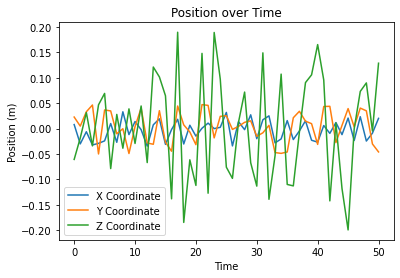

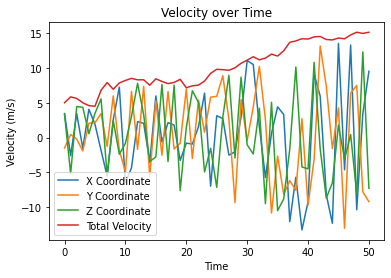

In [121]:
badParticle = 0
path = diffuseResults[1]['x'][:,badParticle,:]
time = np.arange(path.shape[0])
plt.plot(time, path[:,0], label='X Coordinate')
plt.plot(time, path[:,1], label='Y Coordinate')
plt.plot(time, path[:,2], label='Z Coordinate')
plt.legend()
plt.xlabel("Time")
plt.ylabel('Position (m)')
plt.title('Position over Time')
plt.show()

path = diffuseResults[1]['v'][:,badParticle,:]
time = np.arange(path.shape[0])
plt.plot(time, path[:,0], label='X Coordinate')
plt.plot(time, path[:,1], label='Y Coordinate')
plt.plot(time, path[:,2], label='Z Coordinate')
plt.plot(time, np.sqrt(np.sum(np.square(path), axis=1)), label='Total Velocity')
plt.legend()
plt.xlabel("Time")
plt.ylabel('Velocity (m/s)')
plt.title('Velocity over Time')
plt.show()

In [116]:
goodSpecular[:,0].shape

(12231,)